## 1. 环境、依赖与 GPU

In [2]:
import torch

print("PyTorch version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 5060


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ==============================
# 随机种子
# ==============================

torch.manual_seed(42)
np.random.seed(42)


# ==============================
# 设备
# ==============================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 5060


## 2. 厚壁圆管的几何、材料与载荷参数

In [3]:
# ==============================
# 厚壁圆管的几何参数
# ==============================

R_i = 0.5      # 内半径
R_o = 1.0      # 外半径


# ==============================
# 材料参数
# ==============================

E = 1.0        # 杨氏模量
nu = 0.3       # 泊松比


# ==============================
# 压力边界条件
# ==============================

p_i = 1.0      # 内壁压力
p_o = 0.0      # 外壁压力


# ==============================
# Plane Strain 下的 Lamé 常数
# ==============================

lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu = E / (2.0 * (1.0 + nu))


print("R_i =", R_i)
print("R_o =", R_o)

print("E =", E)
print("nu =", nu)

print("p_i =", p_i)
print("p_o =", p_o)

print("lambda =", lam)
print("mu =", mu)

R_i = 0.5
R_o = 1.0
E = 1.0
nu = 0.3
p_i = 1.0
p_o = 0.0
lambda = 0.5769230769230769
mu = 0.3846153846153846


## 3. 生成圆管内部点与边界点

In [5]:
# ==============================
# 采样点数量
# ==============================

N_i = 10000      # 管壁内部点
N_inner = 500    # 内壁边界点
N_outer = 500    # 外壁边界点


# ==============================
# 1. 圆环内部均匀采样
# ==============================

xi = torch.rand(N_i, 1, device=device)
theta_i = 2.0 * torch.pi * torch.rand(N_i, 1, device=device)

# 面积均匀采样对应的半径
r_i = torch.sqrt(
    R_i**2 + xi * (R_o**2 - R_i**2)
)

x_i = r_i * torch.cos(theta_i)
y_i = r_i * torch.sin(theta_i)

X_i = torch.cat([x_i, y_i], dim=1)


# ==============================
# 2. 内壁边界点
# ==============================

theta_inner = 2.0 * torch.pi * torch.rand(
    N_inner, 1, device=device
)

x_inner = R_i * torch.cos(theta_inner)
y_inner = R_i * torch.sin(theta_inner)

X_inner = torch.cat(
    [x_inner, y_inner],
    dim=1
)


# ==============================
# 3. 外壁边界点
# ==============================

theta_outer = 2.0 * torch.pi * torch.rand(
    N_outer, 1, device=device
)

x_outer = R_o * torch.cos(theta_outer)
y_outer = R_o * torch.sin(theta_outer)

X_outer = torch.cat(
    [x_outer, y_outer],
    dim=1
)


print("Interior points:", X_i.shape)
print("Inner boundary:", X_inner.shape)
print("Outer boundary:", X_outer.shape)

Interior points: torch.Size([10000, 2])
Inner boundary: torch.Size([500, 2])
Outer boundary: torch.Size([500, 2])


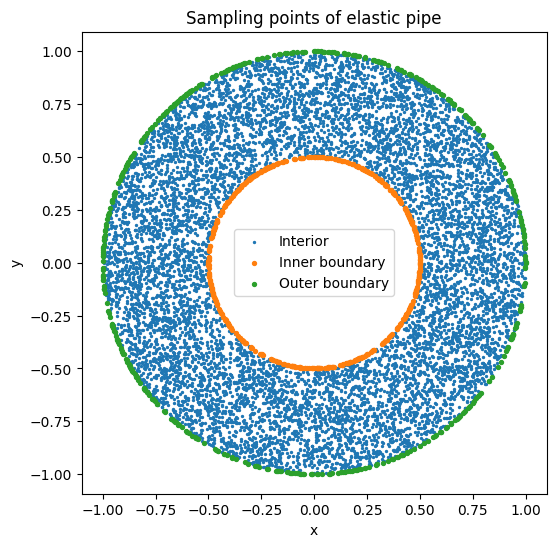

In [6]:
# ==============================
# 可视化采样点
# ==============================

plt.figure(figsize=(6, 6))

plt.scatter(
    X_i[:, 0].detach().cpu(),
    X_i[:, 1].detach().cpu(),
    s=2,
    label="Interior"
)

plt.scatter(
    X_inner[:, 0].detach().cpu(),
    X_inner[:, 1].detach().cpu(),
    s=8,
    label="Inner boundary"
)

plt.scatter(
    X_outer[:, 0].detach().cpu(),
    X_outer[:, 1].detach().cpu(),
    s=8,
    label="Outer boundary"
)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Sampling points of elastic pipe")
plt.show()

## 4. Lamé 厚壁圆管解析解

In [7]:
# ==============================
# Lamé 解析解中的常数 A、B
# ==============================

A_lame = (
    p_i * R_i**2 - p_o * R_o**2
) / (
    R_o**2 - R_i**2
)

B_lame = (
    R_i**2 * R_o**2 * (p_i - p_o)
) / (
    R_o**2 - R_i**2
)


print("A =", A_lame)
print("B =", B_lame)

A = 0.3333333333333333
B = 0.3333333333333333


In [8]:
def lame_solution(X):
    """
    Lamé 厚壁圆管解析解（Plane Strain）

    参数
    ----
    X : torch.Tensor, shape = [N, 2]
        每一行为一个二维坐标点 (x, y)

    返回
    ----
    u_x, u_y:
        x、y 方向解析位移

    sigma_r:
        径向应力

    sigma_theta:
        环向应力
    """

    # 坐标
    x = X[:, 0:1]
    y = X[:, 1:2]

    # 到圆心的距离
    r = torch.sqrt(x**2 + y**2)

    # ==============================
    # 径向应力与环向应力
    # ==============================

    sigma_r = A_lame - B_lame / r**2

    sigma_theta = A_lame + B_lame / r**2


    # ==============================
    # Plane Strain 下的径向位移
    # ==============================

    u_r = (
        (1.0 + nu) / E
        * (
            (1.0 - 2.0 * nu) * A_lame * r
            + B_lame / r
        )
    )


    # ==============================
    # 径向位移转为直角坐标分量
    # ==============================

    u_x = u_r * x / r
    u_y = u_r * y / r

    return u_x, u_y, sigma_r, sigma_theta

In [9]:
# ==============================
# 检查解析解是否满足压力边界
# ==============================

X_check = torch.tensor(
    [
        [R_i, 0.0],    # 内壁
        [R_o, 0.0],    # 外壁
    ],
    dtype=torch.float32,
    device=device
)

u_x_check, u_y_check, sigma_r_check, sigma_theta_check = lame_solution(
    X_check
)

print("Inner sigma_r =", sigma_r_check[0].item())
print("Outer sigma_r =", sigma_r_check[1].item())

print()
print("Expected inner =", -p_i)
print("Expected outer =", -p_o)

Inner sigma_r = -1.0
Outer sigma_r = 0.0

Expected inner = -1.0
Expected outer = -0.0


In [10]:
# ==============================
# 创建解析解可视化点
# ==============================

N_test = 15000

xi_test = torch.rand(
    N_test, 1,
    device=device
)

theta_test = 2.0 * torch.pi * torch.rand(
    N_test, 1,
    device=device
)

r_test = torch.sqrt(
    R_i**2
    + xi_test * (R_o**2 - R_i**2)
)

x_test = r_test * torch.cos(theta_test)
y_test = r_test * torch.sin(theta_test)

X_test = torch.cat(
    [x_test, y_test],
    dim=1
)


# 解析解
u_x_exact, u_y_exact, sigma_r_exact, sigma_theta_exact = lame_solution(
    X_test
)

# 位移大小
u_mag_exact = torch.sqrt(
    u_x_exact**2 + u_y_exact**2
)

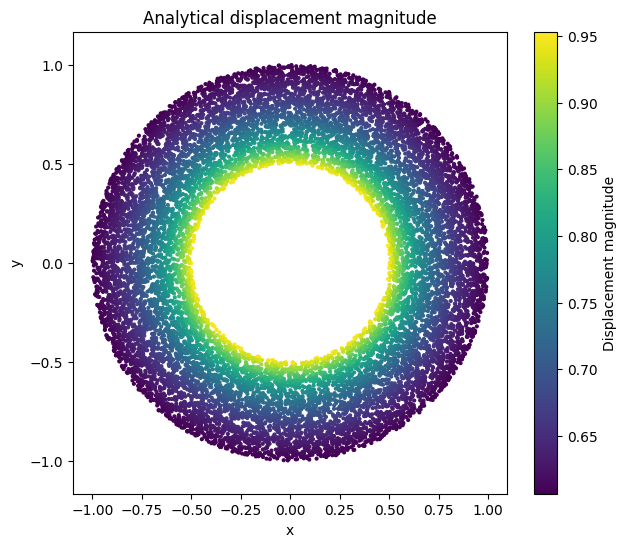

In [11]:
plt.figure(figsize=(7, 6))

plt.scatter(
    X_test[:, 0].detach().cpu(),
    X_test[:, 1].detach().cpu(),
    c=u_mag_exact[:, 0].detach().cpu(),
    s=4
)

plt.colorbar(label="Displacement magnitude")

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")

plt.title("Analytical displacement magnitude")

plt.show()

In [12]:
import torch.nn as nn


class ElasticityNet(nn.Module):
    """
    二维弹性 PINN 网络

    输入:
        (x, y)

    输出:
        (u_x, u_y)
    """

    def __init__(self, layers):
        super().__init__()

        self.layers = nn.ModuleList()

        # 按照 layers 创建全连接层
        for i in range(len(layers) - 1):
            self.layers.append(
                nn.Linear(layers[i], layers[i + 1])
            )

        self.activation = nn.Tanh()

        # Xavier 初始化
        self.apply(self._init_weights)


    def _init_weights(self, module):
        """
        对全连接层进行 Xavier 初始化
        """
        if isinstance(module, nn.Linear):
            nn.init.xavier_normal_(module.weight)
            nn.init.zeros_(module.bias)


    def forward(self, X):
        """
        前向传播

        X.shape = [N, 2]
        输出 shape = [N, 2]
        """

        H = X

        # 最后一层之前全部使用 tanh
        for layer in self.layers[:-1]:
            H = self.activation(layer(H))

        # 输出层不加激活函数
        H = self.layers[-1](H)

        return H

In [13]:
layers = [2, 64, 64, 64, 64, 2]

model_test = ElasticityNet(layers).to(device)

print(model_test)

ElasticityNet(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1-3): 3 x Linear(in_features=64, out_features=64, bias=True)
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
  (activation): Tanh()
)


In [14]:
def gradients(y, x):
    """
    计算 y 对 x 的梯度

    y: [N, 1]
    x: [N, 2]

    返回:
        dy/dx，shape = [N, 2]
    """

    return torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True
    )[0]

In [15]:
def compute_strain(model, X):
    """
    根据神经网络预测位移计算二维应变

    返回:
        u_x, u_y
        eps_xx, eps_yy, eps_xy
    """

    # 自动微分要求输入坐标开启梯度
    X = X.requires_grad_(True)

    # 网络预测位移
    u = model(X)

    u_x = u[:, 0:1]
    u_y = u[:, 1:2]


    # ==============================
    # 位移的一阶导数
    # ==============================

    grad_u_x = gradients(u_x, X)
    grad_u_y = gradients(u_y, X)

    dux_dx = grad_u_x[:, 0:1]
    dux_dy = grad_u_x[:, 1:2]

    duy_dx = grad_u_y[:, 0:1]
    duy_dy = grad_u_y[:, 1:2]


    # ==============================
    # 小变形应变
    # ==============================

    eps_xx = dux_dx

    eps_yy = duy_dy

    eps_xy = 0.5 * (
        dux_dy + duy_dx
    )

    return (
        u_x,
        u_y,
        eps_xx,
        eps_yy,
        eps_xy
    )

In [16]:
def compute_stress(
    eps_xx,
    eps_yy,
    eps_xy
):
    """
    Plane Strain 条件下，
    根据应变计算应力
    """

    # 二维应变迹
    trace_eps = eps_xx + eps_yy


    # 正应力
    sigma_xx = (
        lam * trace_eps
        + 2.0 * mu * eps_xx
    )

    sigma_yy = (
        lam * trace_eps
        + 2.0 * mu * eps_yy
    )


    # 剪切应力
    sigma_xy = (
        2.0 * mu * eps_xy
    )

    return (
        sigma_xx,
        sigma_yy,
        sigma_xy
    )

In [17]:
def displacement_strain_stress(model, X):
    """
    一次性得到：
    位移 → 应变 → 应力
    """

    (
        u_x,
        u_y,
        eps_xx,
        eps_yy,
        eps_xy
    ) = compute_strain(model, X)

    (
        sigma_xx,
        sigma_yy,
        sigma_xy
    ) = compute_stress(
        eps_xx,
        eps_yy,
        eps_xy
    )

    return (
        u_x,
        u_y,
        eps_xx,
        eps_yy,
        eps_xy,
        sigma_xx,
        sigma_yy,
        sigma_xy
    )

In [18]:
def compute_pde_residual(model, X):
    """
    计算二维线弹性静力平衡方程残差

    PDE:
        dσ_xx/dx + dσ_xy/dy = 0
        dσ_xy/dx + dσ_yy/dy = 0

    注意：
    σ 本身已经包含位移的一阶导数，
    因此这里再次求导会产生位移的二阶导数。
    """

    # 为了进行自动微分，复制并开启梯度
    X = X.clone().detach().requires_grad_(True)

    (
        u_x,
        u_y,
        eps_xx,
        eps_yy,
        eps_xy,
        sigma_xx,
        sigma_yy,
        sigma_xy
    ) = displacement_strain_stress(model, X)


    # ==============================
    # 对应力再次进行自动微分
    # ==============================

    grad_sigma_xx = gradients(
        sigma_xx,
        X
    )

    grad_sigma_yy = gradients(
        sigma_yy,
        X
    )

    grad_sigma_xy = gradients(
        sigma_xy,
        X
    )


    # ==============================
    # 提取需要的空间偏导
    # ==============================

    dsigma_xx_dx = grad_sigma_xx[:, 0:1]

    dsigma_xy_dy = grad_sigma_xy[:, 1:2]

    dsigma_xy_dx = grad_sigma_xy[:, 0:1]

    dsigma_yy_dy = grad_sigma_yy[:, 1:2]


    # ==============================
    # 静力平衡方程残差
    # ==============================

    residual_x = (
        dsigma_xx_dx
        + dsigma_xy_dy
    )

    residual_y = (
        dsigma_xy_dx
        + dsigma_yy_dy
    )

    return residual_x, residual_y

In [19]:
def compute_traction(model, X, n_x, n_y):
    """
    根据应力张量和边界外法向量计算 traction

        t = sigma @ n

    返回:
        t_x, t_y
    """

    (
        u_x,
        u_y,
        eps_xx,
        eps_yy,
        eps_xy,
        sigma_xx,
        sigma_yy,
        sigma_xy
    ) = displacement_strain_stress(model, X)


    # t_x = sigma_xx * n_x + sigma_xy * n_y
    t_x = (
        sigma_xx * n_x
        + sigma_xy * n_y
    )

    # t_y = sigma_xy * n_x + sigma_yy * n_y
    t_y = (
        sigma_xy * n_x
        + sigma_yy * n_y
    )

    return t_x, t_y

In [20]:
# ==============================
# 内壁边界法向量
# ==============================

n_inner_x = -X_inner[:, 0:1] / R_i
n_inner_y = -X_inner[:, 1:2] / R_i


# 内压对应的目标 traction
t_inner_x_target = -p_i * n_inner_x
t_inner_y_target = -p_i * n_inner_y

In [21]:
# ==============================
# 外壁边界法向量
# ==============================

n_outer_x = X_outer[:, 0:1] / R_o
n_outer_y = X_outer[:, 1:2] / R_o


# 外壁没有压力
t_outer_x_target = torch.zeros_like(n_outer_x)
t_outer_y_target = torch.zeros_like(n_outer_y)

In [22]:
def residual_loss(
    model,
    X_i,
    X_inner,
    X_outer
):
    """
    Residual PINN 总损失：

        PDE 平衡方程残差
        + 内壁压力边界
        + 外壁自由边界
    """

    # ==============================
    # 1. PDE residual
    # ==============================

    residual_x, residual_y = compute_pde_residual(
        model,
        X_i
    )

    loss_pde = (
        torch.mean(residual_x**2)
        +
        torch.mean(residual_y**2)
    )


    # ==============================
    # 2. 内壁压力边界
    # ==============================

    X_inner_grad = (
        X_inner.clone()
        .detach()
        .requires_grad_(True)
    )

    n_inner_x = -X_inner_grad[:, 0:1] / R_i
    n_inner_y = -X_inner_grad[:, 1:2] / R_i

    t_inner_x, t_inner_y = compute_traction(
        model,
        X_inner_grad,
        n_inner_x,
        n_inner_y
    )

    target_inner_x = -p_i * n_inner_x
    target_inner_y = -p_i * n_inner_y

    loss_inner = (
        torch.mean(
            (t_inner_x - target_inner_x)**2
        )
        +
        torch.mean(
            (t_inner_y - target_inner_y)**2
        )
    )


    # ==============================
    # 3. 外壁自由边界
    # ==============================

    X_outer_grad = (
        X_outer.clone()
        .detach()
        .requires_grad_(True)
    )

    n_outer_x = X_outer_grad[:, 0:1] / R_o
    n_outer_y = X_outer_grad[:, 1:2] / R_o

    t_outer_x, t_outer_y = compute_traction(
        model,
        X_outer_grad,
        n_outer_x,
        n_outer_y
    )

    loss_outer = (
        torch.mean(t_outer_x**2)
        +
        torch.mean(t_outer_y**2)
    )


    # ==============================
    # 总损失
    # ==============================

    loss = (
        loss_pde
        + loss_inner
        + loss_outer
    )

    return (
        loss,
        loss_pde,
        loss_inner,
        loss_outer
    )

In [23]:
model_residual_test = ElasticityNet(
    layers
).to(device)

(
    loss,
    loss_pde,
    loss_inner,
    loss_outer
) = residual_loss(
    model_residual_test,
    X_i,
    X_inner,
    X_outer
)

print("Total loss :", loss.item())
print("PDE loss   :", loss_pde.item())
print("Inner loss :", loss_inner.item())
print("Outer loss :", loss_outer.item())

Total loss : 1.759026288986206
PDE loss   : 0.03334558755159378
Inner loss : 1.6187422275543213
Outer loss : 0.1069384515285492


In [24]:
# ==============================
# 刚体运动约束点
# ==============================

X_anchor = torch.tensor(
    [
        [R_o, 0.0],   # P1
        [0.0, R_o],   # P2
    ],
    dtype=torch.float32,
    device=device
)

# 只在这里取得锚点对应的解析位移
u_x_anchor_exact, u_y_anchor_exact, _, _ = lame_solution(
    X_anchor
)

print("Anchor points:")
print(X_anchor)

print("\nExact ux:")
print(u_x_anchor_exact)

print("\nExact uy:")
print(u_y_anchor_exact)

Anchor points:
tensor([[1., 0.],
        [0., 1.]], device='cuda:0')

Exact ux:
tensor([[0.6067],
        [0.0000]], device='cuda:0')

Exact uy:
tensor([[0.0000],
        [0.6067]], device='cuda:0')


In [25]:
def anchor_loss(model):
    """
    使用两个锚点消除二维弹性问题中的刚体自由度。

    P1 = (R_o, 0):
        约束 ux 为解析径向位移
        约束 uy = 0

    P2 = (0, R_o):
        约束 ux = 0
    """

    u_pred = model(X_anchor)

    # P1
    loss_p1 = (
        (u_pred[0, 0] - u_x_anchor_exact[0, 0])**2
        +
        u_pred[0, 1]**2
    )

    # P2
    loss_p2 = (
        u_pred[1, 0]**2
    )

    return loss_p1 + loss_p2

In [26]:
loss_anchor = anchor_loss(
    model_residual_test
)

print("Anchor loss:", loss_anchor.item())

Anchor loss: 0.7710663676261902


In [27]:
def total_residual_loss(
    model,
    X_i,
    X_inner,
    X_outer,
    w_anchor=10.0
):
    """
    Residual PINN 最终训练损失
    """

    (
        loss_physics,
        loss_pde,
        loss_inner,
        loss_outer
    ) = residual_loss(
        model,
        X_i,
        X_inner,
        X_outer
    )

    loss_anchor = anchor_loss(model)

    loss_total = (
        loss_physics
        + w_anchor * loss_anchor
    )

    return (
        loss_total,
        loss_pde,
        loss_inner,
        loss_outer,
        loss_anchor
    )

In [28]:
(
    loss_total,
    loss_pde,
    loss_inner,
    loss_outer,
    loss_anchor
) = total_residual_loss(
    model_residual_test,
    X_i,
    X_inner,
    X_outer
)

print("Total loss  :", loss_total.item())
print("PDE loss    :", loss_pde.item())
print("Inner loss  :", loss_inner.item())
print("Outer loss  :", loss_outer.item())
print("Anchor loss :", loss_anchor.item())

Total loss  : 9.469690322875977
PDE loss    : 0.03334558755159378
Inner loss  : 1.6187422275543213
Outer loss  : 0.1069384515285492
Anchor loss : 0.7710663676261902


In [29]:
# ==============================
# 创建 Residual PINN
# ==============================

# 固定随机种子，便于以后和 Energy PINN 公平比较
torch.manual_seed(42)

model_residual = ElasticityNet(
    layers
).to(device)


# ==============================
# Adam 优化器
# ==============================

optimizer_residual = torch.optim.Adam(
    model_residual.parameters(),
    lr=1e-3
)


# ==============================
# 保存训练历史
# ==============================

history_residual = {
    "total": [],
    "pde": [],
    "inner": [],
    "outer": [],
    "anchor": []
}


epochs = 1000

In [30]:
for epoch in range(1, epochs + 1):

    optimizer_residual.zero_grad()

    (
        loss_total,
        loss_pde,
        loss_inner,
        loss_outer,
        loss_anchor
    ) = total_residual_loss(
        model_residual,
        X_i,
        X_inner,
        X_outer
    )

    # 反向传播
    loss_total.backward()

    # 更新网络参数
    optimizer_residual.step()


    # ==============================
    # 保存 loss
    # ==============================

    history_residual["total"].append(
        loss_total.item()
    )

    history_residual["pde"].append(
        loss_pde.item()
    )

    history_residual["inner"].append(
        loss_inner.item()
    )

    history_residual["outer"].append(
        loss_outer.item()
    )

    history_residual["anchor"].append(
        loss_anchor.item()
    )


    # 每 100 轮打印一次
    if epoch == 1 or epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Total {loss_total.item():.3e} | "
            f"PDE {loss_pde.item():.3e} | "
            f"Inner {loss_inner.item():.3e} | "
            f"Outer {loss_outer.item():.3e} | "
            f"Anchor {loss_anchor.item():.3e}"
        )

Epoch    1 | Total 6.158e+00 | PDE 1.077e-01 | Inner 2.782e+00 | Outer 3.069e-01 | Anchor 2.961e-01
Epoch  100 | Total 5.166e-01 | PDE 5.132e-02 | Inner 2.597e-01 | Outer 2.033e-01 | Anchor 2.304e-04
Epoch  200 | Total 4.757e-01 | PDE 4.756e-02 | Inner 2.226e-01 | Outer 2.052e-01 | Anchor 2.408e-05
Epoch  300 | Total 4.683e-01 | PDE 4.128e-02 | Inner 2.177e-01 | Outer 2.093e-01 | Anchor 7.530e-06
Epoch  400 | Total 4.650e-01 | PDE 3.902e-02 | Inner 2.157e-01 | Outer 2.102e-01 | Anchor 3.346e-06
Epoch  500 | Total 4.631e-01 | PDE 3.810e-02 | Inner 2.145e-01 | Outer 2.105e-01 | Anchor 1.666e-06
Epoch  600 | Total 4.620e-01 | PDE 3.777e-02 | Inner 2.133e-01 | Outer 2.108e-01 | Anchor 2.553e-06
Epoch  700 | Total 4.614e-01 | PDE 3.765e-02 | Inner 2.122e-01 | Outer 2.115e-01 | Anchor 1.356e-05
Epoch  800 | Total 4.614e-01 | PDE 3.697e-02 | Inner 2.149e-01 | Outer 2.091e-01 | Anchor 4.541e-05
Epoch  900 | Total 4.606e-01 | PDE 3.733e-02 | Inner 2.125e-01 | Outer 2.107e-01 | Anchor 2.042e-07


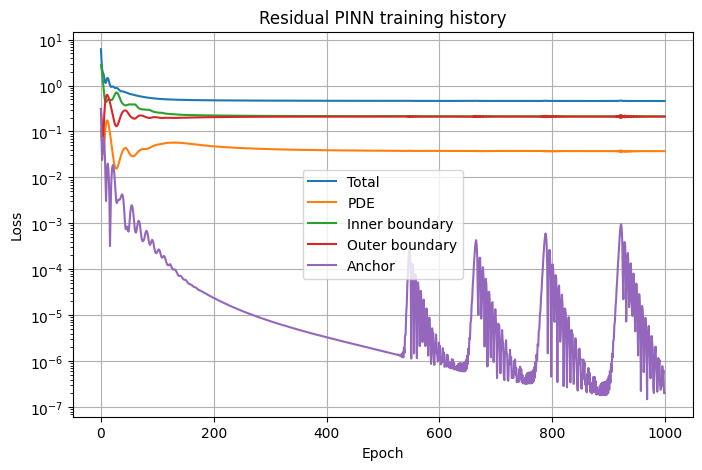

In [31]:
plt.figure(figsize=(8, 5))

plt.semilogy(
    history_residual["total"],
    label="Total"
)

plt.semilogy(
    history_residual["pde"],
    label="PDE"
)

plt.semilogy(
    history_residual["inner"],
    label="Inner boundary"
)

plt.semilogy(
    history_residual["outer"],
    label="Outer boundary"
)

plt.semilogy(
    history_residual["anchor"],
    label="Anchor"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Residual PINN training history")
plt.legend()
plt.grid(True)

plt.show()

In [32]:
# ==============================
# Residual PINN 在测试点上的预测
# ==============================

model_residual.eval()

with torch.no_grad():

    u_pred_residual = model_residual(X_test)

    u_x_pred_residual = u_pred_residual[:, 0:1]
    u_y_pred_residual = u_pred_residual[:, 1:2]

    u_mag_pred_residual = torch.sqrt(
        u_x_pred_residual**2
        +
        u_y_pred_residual**2
    )

In [33]:
# ==============================
# 构造解析位移向量
# ==============================

u_exact = torch.cat(
    [
        u_x_exact,
        u_y_exact
    ],
    dim=1
)


# ==============================
# 相对 L2 误差
# ==============================

relative_l2_residual = (
    torch.linalg.norm(
        u_pred_residual - u_exact
    )
    /
    torch.linalg.norm(
        u_exact
    )
)

print(
    "Residual PINN Relative L2 =",
    relative_l2_residual.item()
)

Residual PINN Relative L2 = 2.382040023803711


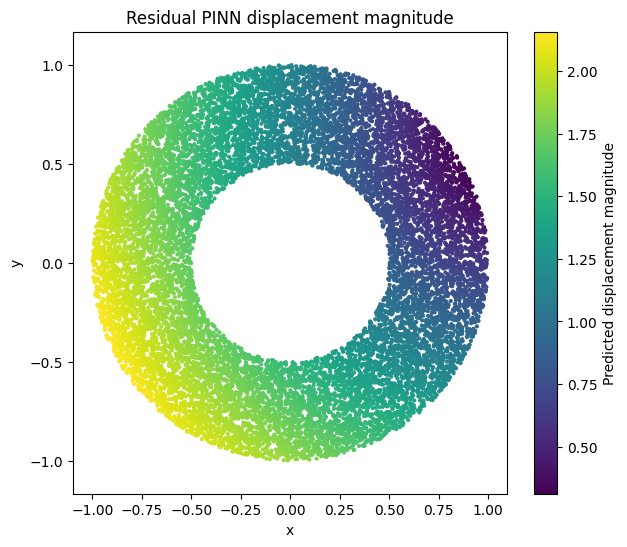

In [34]:
plt.figure(figsize=(7, 6))

plt.scatter(
    X_test[:, 0].detach().cpu(),
    X_test[:, 1].detach().cpu(),
    c=u_mag_pred_residual[:, 0].detach().cpu(),
    s=4
)

plt.colorbar(
    label="Predicted displacement magnitude"
)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")

plt.title(
    "Residual PINN displacement magnitude"
)

plt.show()

In [35]:
# ============================================================
# 21. 二维受载弹性板 Benchmark
#
# 使用二维矩形弹性板作为新的对照问题：
# - 区域：(x, y) ∈ [0, 1] × [0, 1]
# - 左边界固定：u_x = u_y = 0
# - 右边界施加水平拉力：t_x = T, t_y = 0
# - 上、下边界为自由边界
#
# 采用 Plane Strain 模型，并沿用 E = 1, nu = 0.3。
# ============================================================

Lx = 1.0
Ly = 1.0

# 右边界水平拉力
T = 1.0

# 材料参数
E = 1.0
nu = 0.3

# Plane Strain Lamé 常数
lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu = E / (2.0 * (1.0 + nu))

print("Lx =", Lx)
print("Ly =", Ly)
print("T =", T)
print("lambda =", lam)
print("mu =", mu)

Lx = 1.0
Ly = 1.0
T = 1.0
lambda = 0.5769230769230769
mu = 0.3846153846153846


In [36]:
# ============================================================
# 22. 生成二维弹性板训练采样点
#
# 这里生成五类点：
# 1. 内部点：用于计算 PDE residual / 能量积分
# 2. 左边界：固定边界
# 3. 右边界：施加水平 traction
# 4. 上边界：自由边界
# 5. 下边界：自由边界
#
# 第一轮仍使用 10000 个内部点，每条边界 500 个点。
# ============================================================

# 采样点数量
N_i_plate = 10000
N_b_plate = 500


# ==============================
# 1. 内部点
# ==============================

x_i_plate = Lx * torch.rand(
    N_i_plate, 1,
    device=device
)

y_i_plate = Ly * torch.rand(
    N_i_plate, 1,
    device=device
)

X_i_plate = torch.cat(
    [x_i_plate, y_i_plate],
    dim=1
)


# ==============================
# 2. 左边界 x = 0
# ==============================

y_left = Ly * torch.rand(
    N_b_plate, 1,
    device=device
)

x_left = torch.zeros_like(y_left)

X_left = torch.cat(
    [x_left, y_left],
    dim=1
)


# ==============================
# 3. 右边界 x = Lx
# ==============================

y_right = Ly * torch.rand(
    N_b_plate, 1,
    device=device
)

x_right = torch.full_like(
    y_right,
    Lx
)

X_right = torch.cat(
    [x_right, y_right],
    dim=1
)


# ==============================
# 4. 上边界 y = Ly
# ==============================

x_top = Lx * torch.rand(
    N_b_plate, 1,
    device=device
)

y_top = torch.full_like(
    x_top,
    Ly
)

X_top = torch.cat(
    [x_top, y_top],
    dim=1
)


# ==============================
# 5. 下边界 y = 0
# ==============================

x_bottom = Lx * torch.rand(
    N_b_plate, 1,
    device=device
)

y_bottom = torch.zeros_like(x_bottom)

X_bottom = torch.cat(
    [x_bottom, y_bottom],
    dim=1
)


print("Interior :", X_i_plate.shape)
print("Left     :", X_left.shape)
print("Right    :", X_right.shape)
print("Top      :", X_top.shape)
print("Bottom   :", X_bottom.shape)

Interior : torch.Size([10000, 2])
Left     : torch.Size([500, 2])
Right    : torch.Size([500, 2])
Top      : torch.Size([500, 2])
Bottom   : torch.Size([500, 2])


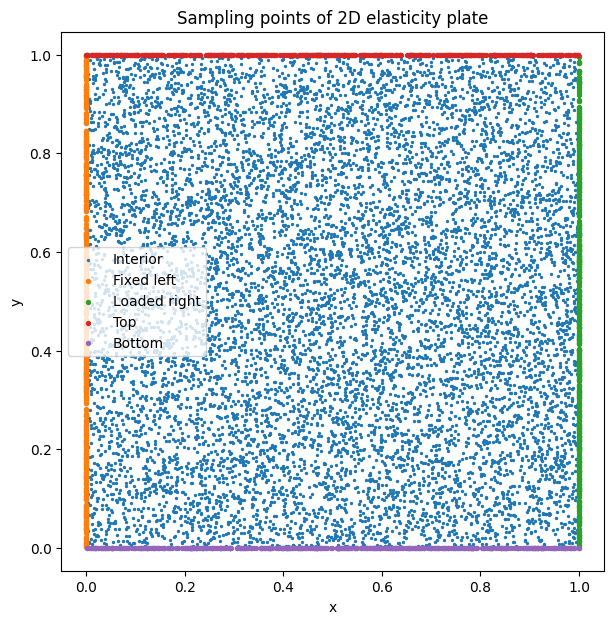

In [37]:
# ============================================================
# 23. 可视化二维弹性板采样点
#
# 这一格只做几何检查。
# 目的是确认内部点覆盖整个矩形区域，
# 四条边界点也都落在正确的位置。
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    X_i_plate[:, 0].cpu(),
    X_i_plate[:, 1].cpu(),
    s=2,
    label="Interior"
)

plt.scatter(
    X_left[:, 0].cpu(),
    X_left[:, 1].cpu(),
    s=8,
    label="Fixed left"
)

plt.scatter(
    X_right[:, 0].cpu(),
    X_right[:, 1].cpu(),
    s=8,
    label="Loaded right"
)

plt.scatter(
    X_top[:, 0].cpu(),
    X_top[:, 1].cpu(),
    s=8,
    label="Top"
)

plt.scatter(
    X_bottom[:, 0].cpu(),
    X_bottom[:, 1].cpu(),
    s=8,
    label="Bottom"
)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sampling points of 2D elasticity plate")
plt.legend()

plt.show()

In [38]:
# ============================================================
# 24. 定义二维弹性板的 Residual PINN Loss
#
# 总损失包含：
# 1. 内部静力平衡 PDE residual
# 2. 左边界位移约束
# 3. 右边界 traction
# 4. 上边界自由条件
# 5. 下边界自由条件
#
# PDE 部分仍然调用前面已经写好的 compute_pde_residual()，
# 因此仍然包含位移的二阶自动微分。
# ============================================================

def residual_loss_plate(
    model,
    X_i,
    X_left,
    X_right,
    X_top,
    X_bottom,
    w_dirichlet=10.0
):
    # ==============================
    # 1. PDE residual
    # ==============================

    residual_x, residual_y = compute_pde_residual(
        model,
        X_i
    )

    loss_pde = (
        torch.mean(residual_x**2)
        +
        torch.mean(residual_y**2)
    )


    # ==============================
    # 2. 左边界固定：u_x = u_y = 0
    # ==============================

    u_left = model(X_left)

    loss_left = (
        torch.mean(u_left[:, 0:1]**2)
        +
        torch.mean(u_left[:, 1:2]**2)
    )


    # ==============================
    # 3. 右边界 traction
    #
    # n = (1, 0)
    # 目标：
    # t_x = T
    # t_y = 0
    # ==============================

    X_right_grad = (
        X_right.clone()
        .detach()
        .requires_grad_(True)
    )

    n_right_x = torch.ones_like(
        X_right_grad[:, 0:1]
    )

    n_right_y = torch.zeros_like(
        X_right_grad[:, 1:2]
    )

    t_right_x, t_right_y = compute_traction(
        model,
        X_right_grad,
        n_right_x,
        n_right_y
    )

    loss_right = (
        torch.mean(
            (t_right_x - T)**2
        )
        +
        torch.mean(
            t_right_y**2
        )
    )


    # ==============================
    # 4. 上边界自由
    #
    # n = (0, 1)
    # 目标 traction = 0
    # ==============================

    X_top_grad = (
        X_top.clone()
        .detach()
        .requires_grad_(True)
    )

    n_top_x = torch.zeros_like(
        X_top_grad[:, 0:1]
    )

    n_top_y = torch.ones_like(
        X_top_grad[:, 1:2]
    )

    t_top_x, t_top_y = compute_traction(
        model,
        X_top_grad,
        n_top_x,
        n_top_y
    )

    loss_top = (
        torch.mean(t_top_x**2)
        +
        torch.mean(t_top_y**2)
    )


    # ==============================
    # 5. 下边界自由
    #
    # n = (0, -1)
    # 目标 traction = 0
    # ==============================

    X_bottom_grad = (
        X_bottom.clone()
        .detach()
        .requires_grad_(True)
    )

    n_bottom_x = torch.zeros_like(
        X_bottom_grad[:, 0:1]
    )

    n_bottom_y = -torch.ones_like(
        X_bottom_grad[:, 1:2]
    )

    t_bottom_x, t_bottom_y = compute_traction(
        model,
        X_bottom_grad,
        n_bottom_x,
        n_bottom_y
    )

    loss_bottom = (
        torch.mean(t_bottom_x**2)
        +
        torch.mean(t_bottom_y**2)
    )


    # ==============================
    # 总损失
    # ==============================

    loss_total = (
        loss_pde
        + w_dirichlet * loss_left
        + loss_right
        + loss_top
        + loss_bottom
    )

    return (
        loss_total,
        loss_pde,
        loss_left,
        loss_right,
        loss_top,
        loss_bottom
    )

In [39]:
# ============================================================
# 25. 前向检查
#
# 随机初始化一个网络，只计算一次完整 loss。
# 这里不关心 loss 数值大小，只检查：
# - 能否正常运行
# - 是否出现 NaN
# - 是否发生 CUDA OOM
# ============================================================

torch.manual_seed(42)

model_plate_test = ElasticityNet(
    layers
).to(device)

(
    loss_total,
    loss_pde,
    loss_left,
    loss_right,
    loss_top,
    loss_bottom
) = residual_loss_plate(
    model_plate_test,
    X_i_plate,
    X_left,
    X_right,
    X_top,
    X_bottom
)

print("Total  :", loss_total.item())
print("PDE    :", loss_pde.item())
print("Left   :", loss_left.item())
print("Right  :", loss_right.item())
print("Top    :", loss_top.item())
print("Bottom :", loss_bottom.item())

Total  : 2.2689614295959473
PDE    : 0.06997747719287872
Left   : 0.11842703074216843
Right  : 0.239443838596344
Top    : 0.2768987715244293
Bottom : 0.49837106466293335


In [40]:
# ============================================================
# 26. 二维弹性板 Residual PINN：1000 epoch 短训练
#
# 这一轮只做 sanity check：
# - 确认 PDE residual 能下降
# - 确认左侧固定边界能满足
# - 确认右侧 traction 和上下自由边界能逐步满足
#
# 暂时不计时、不用 L-BFGS。
# ============================================================

torch.manual_seed(42)

model_plate_residual = ElasticityNet(
    layers
).to(device)

optimizer_plate_residual = torch.optim.Adam(
    model_plate_residual.parameters(),
    lr=1e-3
)

history_plate_residual = {
    "total": [],
    "pde": [],
    "left": [],
    "right": [],
    "top": [],
    "bottom": []
}

epochs_plate = 1000


for epoch in range(1, epochs_plate + 1):

    optimizer_plate_residual.zero_grad()

    (
        loss_total,
        loss_pde,
        loss_left,
        loss_right,
        loss_top,
        loss_bottom
    ) = residual_loss_plate(
        model_plate_residual,
        X_i_plate,
        X_left,
        X_right,
        X_top,
        X_bottom
    )

    # 反向传播
    loss_total.backward()

    # 参数更新
    optimizer_plate_residual.step()


    # ==============================
    # 保存 loss
    # ==============================

    history_plate_residual["total"].append(
        loss_total.item()
    )

    history_plate_residual["pde"].append(
        loss_pde.item()
    )

    history_plate_residual["left"].append(
        loss_left.item()
    )

    history_plate_residual["right"].append(
        loss_right.item()
    )

    history_plate_residual["top"].append(
        loss_top.item()
    )

    history_plate_residual["bottom"].append(
        loss_bottom.item()
    )


    # 每 100 轮打印一次
    if epoch == 1 or epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Total {loss_total.item():.3e} | "
            f"PDE {loss_pde.item():.3e} | "
            f"Left {loss_left.item():.3e} | "
            f"Right {loss_right.item():.3e} | "
            f"Top {loss_top.item():.3e} | "
            f"Bottom {loss_bottom.item():.3e}"
        )

Epoch    1 | Total 2.269e+00 | PDE 6.998e-02 | Left 1.184e-01 | Right 2.394e-01 | Top 2.769e-01 | Bottom 4.984e-01
Epoch  100 | Total 1.008e-01 | PDE 2.650e-03 | Left 6.015e-03 | Right 1.349e-02 | Top 1.097e-02 | Bottom 1.356e-02
Epoch  200 | Total 7.588e-02 | PDE 3.115e-03 | Left 4.550e-03 | Right 7.707e-03 | Top 8.483e-03 | Bottom 1.108e-02
Epoch  300 | Total 5.107e-02 | PDE 9.227e-03 | Left 2.178e-03 | Right 4.778e-03 | Top 9.798e-03 | Bottom 5.490e-03
Epoch  400 | Total 4.102e-02 | PDE 8.026e-03 | Left 1.443e-03 | Right 2.681e-03 | Top 9.206e-03 | Bottom 6.676e-03
Epoch  500 | Total 3.391e-02 | PDE 5.646e-03 | Left 1.037e-03 | Right 1.534e-03 | Top 8.325e-03 | Bottom 8.034e-03
Epoch  600 | Total 2.926e-02 | PDE 4.650e-03 | Left 7.771e-04 | Right 1.366e-03 | Top 8.012e-03 | Bottom 7.464e-03
Epoch  700 | Total 2.722e-02 | PDE 4.128e-03 | Left 6.977e-04 | Right 1.294e-03 | Top 7.743e-03 | Bottom 7.073e-03
Epoch  800 | Total 2.621e-02 | PDE 3.754e-03 | Left 6.294e-04 | Right 9.509e-04 

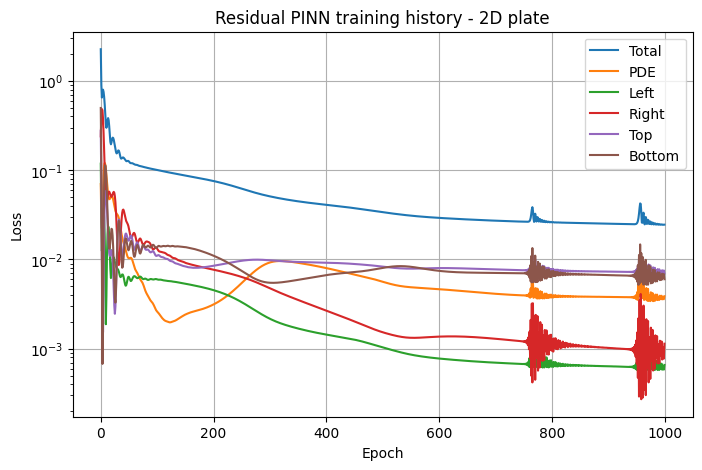

In [41]:
# ============================================================
# 27. 绘制 Residual PINN 训练曲线
#
# 使用对数纵轴观察各项 loss 是否稳定下降。
# ============================================================

plt.figure(figsize=(8, 5))

plt.semilogy(
    history_plate_residual["total"],
    label="Total"
)

plt.semilogy(
    history_plate_residual["pde"],
    label="PDE"
)

plt.semilogy(
    history_plate_residual["left"],
    label="Left"
)

plt.semilogy(
    history_plate_residual["right"],
    label="Right"
)

plt.semilogy(
    history_plate_residual["top"],
    label="Top"
)

plt.semilogy(
    history_plate_residual["bottom"],
    label="Bottom"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Residual PINN training history - 2D plate")
plt.legend()
plt.grid(True)

plt.show()

In [42]:
# ============================================================
# 28. 创建规则测试网格
#
# 用规则网格观察网络预测出来的位移场，
# 比随机散点更容易判断整体物理趋势。
# ============================================================

N_grid = 101

x_grid = torch.linspace(
    0.0,
    Lx,
    N_grid,
    device=device
)

y_grid = torch.linspace(
    0.0,
    Ly,
    N_grid,
    device=device
)

X_mesh, Y_mesh = torch.meshgrid(
    x_grid,
    y_grid,
    indexing="xy"
)

X_test_plate = torch.stack(
    [
        X_mesh.reshape(-1),
        Y_mesh.reshape(-1)
    ],
    dim=1
)


model_plate_residual.eval()

with torch.no_grad():

    u_pred_plate = model_plate_residual(
        X_test_plate
    )

    u_x_plate = u_pred_plate[:, 0].reshape(
        N_grid,
        N_grid
    )

    u_y_plate = u_pred_plate[:, 1].reshape(
        N_grid,
        N_grid
    )

    u_mag_plate = torch.sqrt(
        u_x_plate**2
        +
        u_y_plate**2
    )

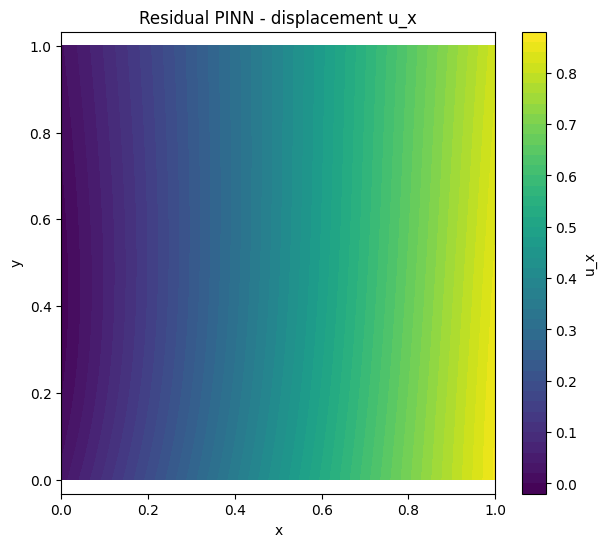

In [43]:
# ============================================================
# 29. 可视化 x 方向位移 u_x
#
# 对右侧施加水平拉力后：
# - 左侧 u_x 应接近 0
# - 向右移动时 u_x 应整体增大
# ============================================================

plt.figure(figsize=(7, 6))

plt.contourf(
    X_mesh.cpu(),
    Y_mesh.cpu(),
    u_x_plate.cpu(),
    levels=50
)

plt.colorbar(label="u_x")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Residual PINN - displacement u_x")

plt.axis("equal")
plt.show()

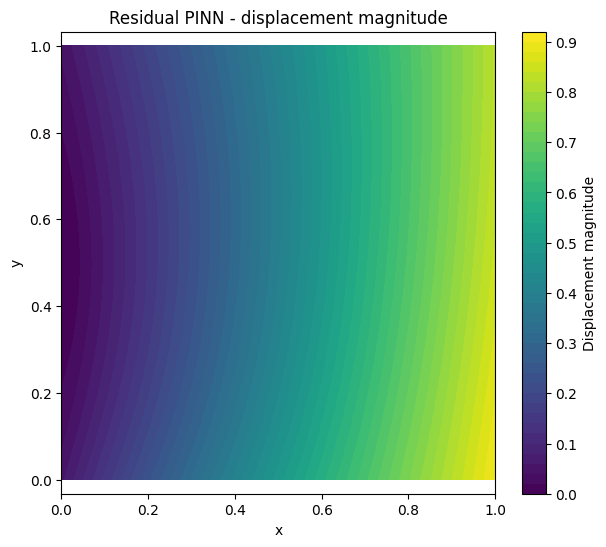

In [44]:
# ============================================================
# 30. 可视化位移模长
#
# 用来观察整个弹性板的变形强度分布。
# ============================================================

plt.figure(figsize=(7, 6))

plt.contourf(
    X_mesh.cpu(),
    Y_mesh.cpu(),
    u_mag_plate.cpu(),
    levels=50
)

plt.colorbar(
    label="Displacement magnitude"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(
    "Residual PINN - displacement magnitude"
)

plt.axis("equal")
plt.show()

In [45]:
# ============================================================
# 31. Energy PINN：计算内部应变能
#
# 能量方法不再计算 div(sigma)，因此不会继续对应力求导。
#
# 网络计算路径：
# (x, y) -> (u_x, u_y) -> strain -> stress -> energy
#
# 这里最高只需要位移的一阶自动微分。
# 内部积分使用 Monte Carlo 方法估计。
# ============================================================

def compute_internal_energy(model, X_i):
    """
    计算二维弹性板的内部应变能 U
    """

    # 内部采样点需要参与自动微分
    X = (
        X_i.clone()
        .detach()
        .requires_grad_(True)
    )

    (
        u_x,
        u_y,
        eps_xx,
        eps_yy,
        eps_xy,
        sigma_xx,
        sigma_yy,
        sigma_xy
    ) = displacement_strain_stress(
        model,
        X
    )


    # ==============================
    # 应变能密度
    #
    # W = 1/2 * sigma : epsilon
    #
    # 因为 epsilon_xy 是张量剪切应变，
    # 剪切项需要乘 2。
    # ==============================

    energy_density = 0.5 * (
        sigma_xx * eps_xx
        +
        sigma_yy * eps_yy
        +
        2.0 * sigma_xy * eps_xy
    )


    # ==============================
    # Monte Carlo 面积积分
    #
    # ∫_Ω W dΩ ≈ Area * mean(W)
    # ==============================

    area = Lx * Ly

    internal_energy = (
        area * torch.mean(energy_density)
    )

    return internal_energy

In [46]:
# ============================================================
# 32. Energy PINN：计算外力势能
#
# 当前只有右边界施加外力：
#
#     t = (T, 0)
#
# 因此外力做功只与右边界的 u_x 有关。
#
# 总势能中的外力项带负号：
#
#     V = - ∫ t · u dΓ
#
# 同样使用 Monte Carlo 方法估计边界积分。
# ============================================================

def compute_external_potential(model, X_right):
    """
    计算右边界 traction 对应的外力势能
    """

    # 网络预测右边界位移
    u_right = model(X_right)

    u_x_right = u_right[:, 0:1]


    # ==============================
    # t · u = T * u_x
    # ==============================

    external_work_density = (
        T * u_x_right
    )


    # ==============================
    # Monte Carlo 边界积分
    # ==============================

    boundary_length = Ly

    external_potential = (
        -boundary_length
        * torch.mean(external_work_density)
    )

    return external_potential

In [47]:
# ============================================================
# 33. Energy PINN：左侧固定边界
#
# Neumann / traction 条件已经自然进入总势能，
# 但 Dirichlet 位移条件仍然需要显式施加。
#
# 第一版使用 penalty 方法：
#
#     u_x = 0
#     u_y = 0
#
# 后面正式实验还可以改成 hard constraint。
# ============================================================

def energy_dirichlet_loss(model, X_left):

    u_left = model(X_left)

    loss_left = (
        torch.mean(
            u_left[:, 0:1]**2
        )
        +
        torch.mean(
            u_left[:, 1:2]**2
        )
    )

    return loss_left

In [48]:
# ============================================================
# 34. Energy PINN：总势能 Loss
#
# 总损失：
#
#     Loss = U + V + w_D * Loss_D
#
# U：内部应变能
# V：外力势能
# Loss_D：左侧固定边界 penalty
#
# 与 Residual PINN 最大区别：
# 这里没有 PDE residual，也没有二阶自动微分。
# ============================================================

def energy_loss_plate(
    model,
    X_i,
    X_left,
    X_right,
    w_dirichlet=10.0
):

    # 内部应变能
    internal_energy = compute_internal_energy(
        model,
        X_i
    )

    # 外力势能
    external_potential = compute_external_potential(
        model,
        X_right
    )

    # 左侧固定边界
    loss_left = energy_dirichlet_loss(
        model,
        X_left
    )


    # ==============================
    # 总势能
    # ==============================

    loss_total = (
        internal_energy
        +
        external_potential
        +
        w_dirichlet * loss_left
    )

    return (
        loss_total,
        internal_energy,
        external_potential,
        loss_left
    )

In [49]:
# ============================================================
# 35. Energy PINN 前向检查
#
# 随机初始化网络，只计算一次总势能。
#
# 注意：
# Energy loss 与 MSE loss 不同，
# 总势能完全可能是负数。
# 因此不要用“loss 必须 > 0”判断是否正常。
# ============================================================

torch.manual_seed(42)

model_plate_energy_test = ElasticityNet(
    layers
).to(device)

(
    loss_energy,
    internal_energy,
    external_potential,
    loss_left_energy
) = energy_loss_plate(
    model_plate_energy_test,
    X_i_plate,
    X_left,
    X_right
)

print(
    "Total energy loss :",
    loss_energy.item()
)

print(
    "Internal energy   :",
    internal_energy.item()
)

print(
    "External potential:",
    external_potential.item()
)

print(
    "Left loss         :",
    loss_left_energy.item()
)

Total energy loss : 1.353919267654419
Internal energy   : 0.2670685946941376
External potential: -0.0974196195602417
Left loss         : 0.11842703074216843


In [50]:
# ============================================================
# 36. Energy PINN：1000 epoch 短训练
#
# 与 Residual PINN 保持相同的网络结构、随机种子、
# Adam 学习率和训练轮数。
#
# 区别只在 Loss：
# Residual PINN 使用 PDE residual + BC MSE；
# Energy PINN 使用总势能 + Dirichlet penalty。
# ============================================================

torch.manual_seed(42)

model_plate_energy = ElasticityNet(
    layers
).to(device)

optimizer_plate_energy = torch.optim.Adam(
    model_plate_energy.parameters(),
    lr=1e-3
)

history_plate_energy = {
    "total": [],
    "internal": [],
    "external": [],
    "left": []
}

epochs_energy = 1000


for epoch in range(1, epochs_energy + 1):

    optimizer_plate_energy.zero_grad()

    (
        loss_total,
        internal_energy,
        external_potential,
        loss_left
    ) = energy_loss_plate(
        model_plate_energy,
        X_i_plate,
        X_left,
        X_right
    )

    # 反向传播
    loss_total.backward()

    # 更新网络参数
    optimizer_plate_energy.step()


    # ==============================
    # 保存训练历史
    # ==============================

    history_plate_energy["total"].append(
        loss_total.item()
    )

    history_plate_energy["internal"].append(
        internal_energy.item()
    )

    history_plate_energy["external"].append(
        external_potential.item()
    )

    history_plate_energy["left"].append(
        loss_left.item()
    )


    # 每 100 轮打印一次
    if epoch == 1 or epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Total {loss_total.item():.3e} | "
            f"Internal {internal_energy.item():.3e} | "
            f"External {external_potential.item():.3e} | "
            f"Left {loss_left.item():.3e}"
        )

Epoch    1 | Total 1.354e+00 | Internal 2.671e-01 | External -9.742e-02 | Left 1.184e-01
Epoch  100 | Total -4.390e-01 | Internal 3.924e-01 | External -8.699e-01 | Left 3.856e-03
Epoch  200 | Total -4.473e-01 | Internal 4.050e-01 | External -8.867e-01 | Left 3.435e-03
Epoch  300 | Total -4.580e-01 | Internal 4.245e-01 | External -9.122e-01 | Left 2.969e-03
Epoch  400 | Total -4.636e-01 | Internal 4.347e-01 | External -9.265e-01 | Left 2.822e-03
Epoch  500 | Total -4.678e-01 | Internal 4.383e-01 | External -9.333e-01 | Left 2.720e-03
Epoch  600 | Total -4.687e-01 | Internal 4.406e-01 | External -9.364e-01 | Left 2.705e-03
Epoch  700 | Total -4.693e-01 | Internal 4.414e-01 | External -9.377e-01 | Left 2.698e-03
Epoch  800 | Total -4.699e-01 | Internal 4.423e-01 | External -9.391e-01 | Left 2.688e-03
Epoch  900 | Total -4.703e-01 | Internal 4.430e-01 | External -9.395e-01 | Left 2.632e-03
Epoch 1000 | Total -4.707e-01 | Internal 4.437e-01 | External -9.411e-01 | Left 2.673e-03


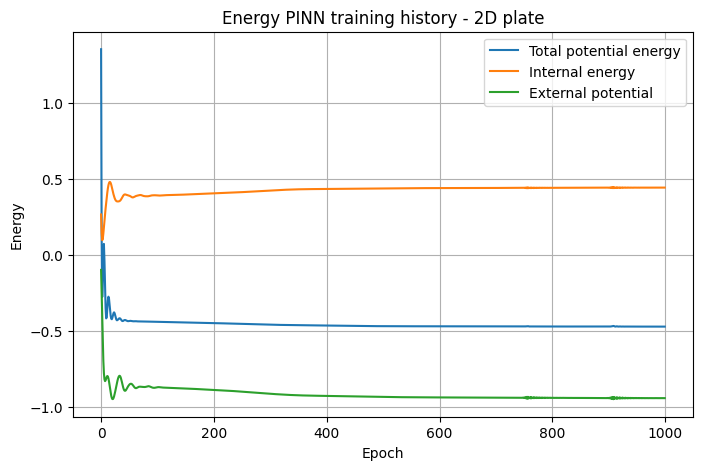

In [51]:
# ============================================================
# 37. Energy PINN 训练曲线
#
# 注意：
# Total / External 可能为负，因此不能直接对它们使用 semilogy。
#
# 这里使用普通坐标观察总势能的下降，
# 再单独观察左侧 Dirichlet penalty。
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_plate_energy["total"],
    label="Total potential energy"
)

plt.plot(
    history_plate_energy["internal"],
    label="Internal energy"
)

plt.plot(
    history_plate_energy["external"],
    label="External potential"
)

plt.xlabel("Epoch")
plt.ylabel("Energy")
plt.title("Energy PINN training history - 2D plate")
plt.legend()
plt.grid(True)

plt.show()

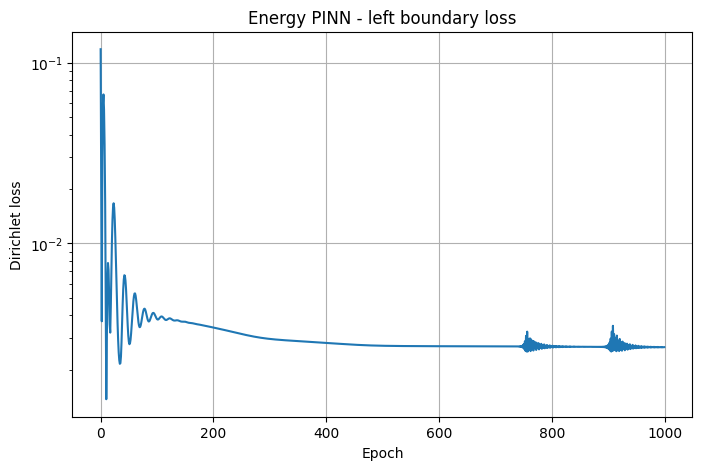

In [52]:
# ============================================================
# 38. Energy PINN 左侧固定边界误差
#
# Dirichlet penalty 应随训练逐步下降。
# ============================================================

plt.figure(figsize=(8, 5))

plt.semilogy(
    history_plate_energy["left"]
)

plt.xlabel("Epoch")
plt.ylabel("Dirichlet loss")
plt.title("Energy PINN - left boundary loss")
plt.grid(True)

plt.show()

In [53]:
# ============================================================
# 39. Energy PINN 在规则测试网格上的预测
#
# 使用前面已经创建的 X_test_plate，
# 这样两种方法的可视化可以直接比较。
# ============================================================

model_plate_energy.eval()

with torch.no_grad():

    u_pred_energy = model_plate_energy(
        X_test_plate
    )

    u_x_energy = u_pred_energy[:, 0].reshape(
        N_grid,
        N_grid
    )

    u_y_energy = u_pred_energy[:, 1].reshape(
        N_grid,
        N_grid
    )

    u_mag_energy = torch.sqrt(
        u_x_energy**2
        +
        u_y_energy**2
    )

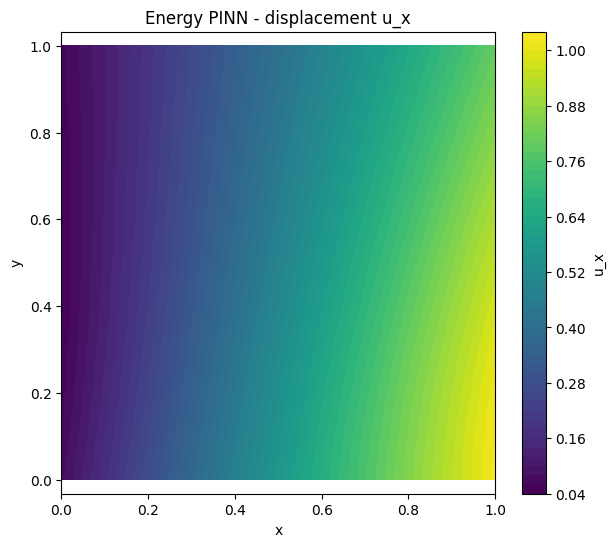

In [54]:
# ============================================================
# 40. Energy PINN：x 方向位移场
#
# 预期趋势应与 Residual PINN 相同：
# 左侧接近 0，向右侧逐渐增大。
# ============================================================

plt.figure(figsize=(7, 6))

plt.contourf(
    X_mesh.cpu(),
    Y_mesh.cpu(),
    u_x_energy.cpu(),
    levels=50
)

plt.colorbar(label="u_x")

plt.xlabel("x")
plt.ylabel("y")

plt.title(
    "Energy PINN - displacement u_x"
)

plt.axis("equal")
plt.show()

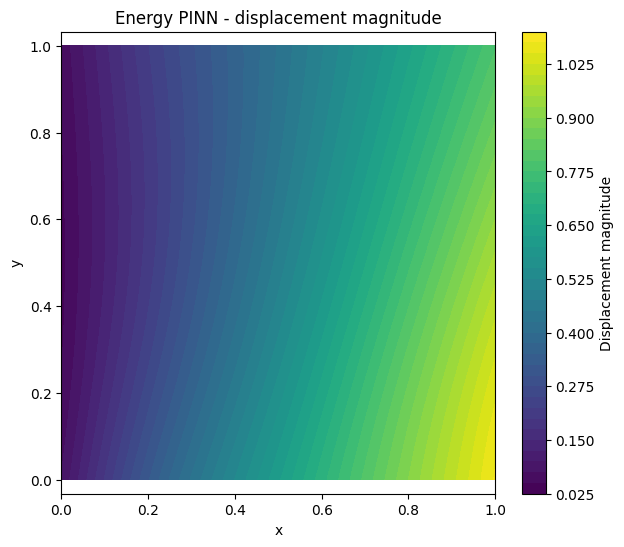

In [55]:
# ============================================================
# 41. Energy PINN：位移模长
# ============================================================

plt.figure(figsize=(7, 6))

plt.contourf(
    X_mesh.cpu(),
    Y_mesh.cpu(),
    u_mag_energy.cpu(),
    levels=50
)

plt.colorbar(
    label="Displacement magnitude"
)

plt.xlabel("x")
plt.ylabel("y")

plt.title(
    "Energy PINN - displacement magnitude"
)

plt.axis("equal")
plt.show()

In [56]:
# ============================================================
# 42. Residual PINN 与 Energy PINN 的预测差异
#
# 这不是“真实误差”，因为 Residual PINN 本身也不是 Ground Truth。
#
# 这里只用于检查两种方法是否收敛到了相近的位移场。
# ============================================================

relative_difference = (
    torch.linalg.norm(
        u_pred_energy - u_pred_plate
    )
    /
    torch.linalg.norm(
        u_pred_plate
    )
)

print(
    "Energy vs Residual relative difference =",
    relative_difference.item()
)

Energy vs Residual relative difference = 0.1972791701555252


In [57]:
# ============================================================
# 43. 比较两种方法的强形式 PDE residual
#
# Residual PINN：
# 训练时直接最小化 PDE residual。
#
# Energy PINN：
# 训练时完全没有使用 PDE residual。
#
# 现在统一用强形式平衡方程检查两个模型，
# 看它们最终是否满足 div(sigma) = 0。
# ============================================================

def evaluate_pde_residual(model, X):

    residual_x, residual_y = compute_pde_residual(
        model,
        X
    )

    mse = (
        torch.mean(residual_x**2)
        +
        torch.mean(residual_y**2)
    )

    return mse.item()


pde_residual_R = evaluate_pde_residual(
    model_plate_residual,
    X_i_plate
)

pde_residual_E = evaluate_pde_residual(
    model_plate_energy,
    X_i_plate
)

print(
    "Residual PINN PDE MSE =",
    pde_residual_R
)

print(
    "Energy PINN PDE MSE   =",
    pde_residual_E
)

Residual PINN PDE MSE = 0.0036542555317282677
Energy PINN PDE MSE   = 0.204086571931839


In [58]:
# ============================================================
# 44. 检查右边界 traction
#
# 统一计算两种模型在右边界上的：
#
#     t_x
#     t_y
#
# 理想结果：
#
#     t_x = 1
#     t_y = 0
#
# Energy PINN 如果能够自然满足该条件，
# 就说明变分形式确实正确地引入了外力边界。
# ============================================================

def evaluate_right_traction(model, X_right):

    X = (
        X_right.clone()
        .detach()
        .requires_grad_(True)
    )

    n_x = torch.ones_like(
        X[:, 0:1]
    )

    n_y = torch.zeros_like(
        X[:, 1:2]
    )

    t_x, t_y = compute_traction(
        model,
        X,
        n_x,
        n_y
    )

    mse = (
        torch.mean((t_x - T)**2)
        +
        torch.mean(t_y**2)
    )

    return (
        torch.mean(t_x).item(),
        torch.mean(t_y).item(),
        mse.item()
    )


R_tx, R_ty, R_traction_mse = evaluate_right_traction(
    model_plate_residual,
    X_right
)

E_tx, E_ty, E_traction_mse = evaluate_right_traction(
    model_plate_energy,
    X_right
)


print("Residual PINN")
print("mean t_x    =", R_tx)
print("mean t_y    =", R_ty)
print("traction MSE=", R_traction_mse)

print()

print("Energy PINN")
print("mean t_x    =", E_tx)
print("mean t_y    =", E_ty)
print("traction MSE=", E_traction_mse)

Residual PINN
mean t_x    = 0.975047767162323
mean t_y    = 0.007350655272603035
traction MSE= 0.0008695785654708743

Energy PINN
mean t_x    = 0.9664433598518372
mean t_y    = 0.010033966973423958
traction MSE= 0.002260203007608652


In [59]:
# ============================================================
# 45. 检查上下自由边界
#
# Energy PINN 训练时没有显式加入上下边界 loss。
#
# 如果变分解正确，自由边界应自然满足：
#
#     traction = 0
# ============================================================

def evaluate_free_boundary(
    model,
    X_boundary,
    n_x_value,
    n_y_value
):

    X = (
        X_boundary.clone()
        .detach()
        .requires_grad_(True)
    )

    n_x = torch.full_like(
        X[:, 0:1],
        n_x_value
    )

    n_y = torch.full_like(
        X[:, 1:2],
        n_y_value
    )

    t_x, t_y = compute_traction(
        model,
        X,
        n_x,
        n_y
    )

    mse = (
        torch.mean(t_x**2)
        +
        torch.mean(t_y**2)
    )

    return mse.item()


for name, model in [
    ("Residual", model_plate_residual),
    ("Energy", model_plate_energy)
]:

    top_mse = evaluate_free_boundary(
        model,
        X_top,
        0.0,
        1.0
    )

    bottom_mse = evaluate_free_boundary(
        model,
        X_bottom,
        0.0,
        -1.0
    )

    print(name)
    print("Top traction MSE    =", top_mse)
    print("Bottom traction MSE =", bottom_mse)
    print()

Residual
Top traction MSE    = 0.007346475496888161
Bottom traction MSE = 0.006574493832886219

Energy
Top traction MSE    = 0.0187875647097826
Bottom traction MSE = 0.032255686819553375



In [60]:
# ============================================================
# 46. 定义带 Hard Dirichlet Constraint 的网络
#
# 左边界要求：
#
#     x = 0  ->  u_x = u_y = 0
#
# 不再使用 penalty loss。
#
# 让原始网络输出：
#
#     u_hat = (u_hat_x, u_hat_y)
#
# 最终物理位移定义为：
#
#     u_x = x * u_hat_x
#     u_y = x * u_hat_y
#
# 因此 x = 0 时位移严格为 0。
# ============================================================

class HardBCElasticityNet(ElasticityNet):

    def forward(self, X):

        # 原始神经网络输出
        H = X

        for layer in self.layers[:-1]:
            H = self.activation(
                layer(H)
            )

        raw_u = self.layers[-1](H)

        # 提取 x 坐标
        x = X[:, 0:1]

        # ==============================
        # Hard Dirichlet Constraint
        # ==============================

        u_x = x * raw_u[:, 0:1]
        u_y = x * raw_u[:, 1:2]

        return torch.cat(
            [u_x, u_y],
            dim=1
        )

In [61]:
# ============================================================
# 47. 检查 Hard Constraint
#
# 随机初始化网络后直接检查左边界。
#
# 即使网络完全没有训练，
# x = 0 上的位移也应该严格等于 0。
# ============================================================

torch.manual_seed(42)

model_hard_test = HardBCElasticityNet(
    layers
).to(device)

with torch.no_grad():

    u_left_test = model_hard_test(
        X_left
    )

print(
    "max |u_x(left)| =",
    torch.max(
        torch.abs(u_left_test[:, 0])
    ).item()
)

print(
    "max |u_y(left)| =",
    torch.max(
        torch.abs(u_left_test[:, 1])
    ).item()
)

max |u_x(left)| = 0.0
max |u_y(left)| = 0.0


In [62]:
# ============================================================
# 48. Hard-BC Energy PINN Loss
#
# 因为网络结构已经严格满足左侧固定条件，
# 不再需要任何 Dirichlet penalty。
#
# 最终训练目标就是纯粹的总势能：
#
#     Pi = U + V
#
# 其中：
# U = 内部应变能
# V = 外力势能
# ============================================================

def energy_loss_plate_hard(
    model,
    X_i,
    X_right
):

    internal_energy = compute_internal_energy(
        model,
        X_i
    )

    external_potential = compute_external_potential(
        model,
        X_right
    )

    loss_total = (
        internal_energy
        +
        external_potential
    )

    return (
        loss_total,
        internal_energy,
        external_potential
    )

In [63]:
# ============================================================
# 49. Hard-BC Energy Loss 前向检查
# ============================================================

(
    loss_total,
    internal_energy,
    external_potential
) = energy_loss_plate_hard(
    model_hard_test,
    X_i_plate,
    X_right
)

print(
    "Total energy      =",
    loss_total.item()
)

print(
    "Internal energy   =",
    internal_energy.item()
)

print(
    "External potential=",
    external_potential.item()
)

Total energy      = 0.00307551771402359
Internal energy   = 0.10049513727426529
External potential= -0.0974196195602417


In [64]:
# ============================================================
# 50. Hard-BC Energy PINN：1000 epoch 短训练
#
# 这一版本不再使用左边界 penalty。
#
# 网络结构本身保证：
#     x = 0 -> u_x = u_y = 0
#
# 因此训练目标只剩：
#     Pi = U + V
#
# 训练时依旧只需要位移的一阶自动微分。
# ============================================================

torch.manual_seed(42)

model_energy_hard = HardBCElasticityNet(
    layers
).to(device)

optimizer_energy_hard = torch.optim.Adam(
    model_energy_hard.parameters(),
    lr=1e-3
)

history_energy_hard = {
    "total": [],
    "internal": [],
    "external": []
}

epochs_energy_hard = 1000


for epoch in range(1, epochs_energy_hard + 1):

    optimizer_energy_hard.zero_grad()

    (
        loss_total,
        internal_energy,
        external_potential
    ) = energy_loss_plate_hard(
        model_energy_hard,
        X_i_plate,
        X_right
    )

    loss_total.backward()

    optimizer_energy_hard.step()


    # ==============================
    # 保存训练历史
    # ==============================

    history_energy_hard["total"].append(
        loss_total.item()
    )

    history_energy_hard["internal"].append(
        internal_energy.item()
    )

    history_energy_hard["external"].append(
        external_potential.item()
    )


    # 每 100 轮打印一次
    if epoch == 1 or epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Total {loss_total.item():.3e} | "
            f"Internal {internal_energy.item():.3e} | "
            f"External {external_potential.item():.3e}"
        )

Epoch    1 | Total 3.076e-03 | Internal 1.005e-01 | External -9.742e-02
Epoch  100 | Total -4.326e-01 | Internal 4.309e-01 | External -8.635e-01
Epoch  200 | Total -4.397e-01 | Internal 4.351e-01 | External -8.748e-01
Epoch  300 | Total -4.418e-01 | Internal 4.411e-01 | External -8.829e-01
Epoch  400 | Total -4.427e-01 | Internal 4.415e-01 | External -8.841e-01
Epoch  500 | Total -4.437e-01 | Internal 4.426e-01 | External -8.863e-01
Epoch  600 | Total -4.435e-01 | Internal 4.145e-01 | External -8.580e-01
Epoch  700 | Total -4.446e-01 | Internal 4.440e-01 | External -8.886e-01
Epoch  800 | Total -4.449e-01 | Internal 4.458e-01 | External -8.907e-01
Epoch  900 | Total -4.452e-01 | Internal 4.442e-01 | External -8.893e-01
Epoch 1000 | Total -4.454e-01 | Internal 4.449e-01 | External -8.903e-01


In [65]:
# ============================================================
# 51. 检查 Hard Dirichlet Boundary
#
# 理论上无论训练前还是训练后，
# 左侧位移都应该严格等于 0。
# ============================================================

model_energy_hard.eval()

with torch.no_grad():

    u_left_hard = model_energy_hard(
        X_left
    )

print(
    "max |u_x(left)| =",
    torch.max(
        torch.abs(u_left_hard[:, 0])
    ).item()
)

print(
    "max |u_y(left)| =",
    torch.max(
        torch.abs(u_left_hard[:, 1])
    ).item()
)

max |u_x(left)| = 0.0
max |u_y(left)| = 0.0


In [66]:
# ============================================================
# 52. 检查 Hard-BC Energy PINN 的强形式 PDE residual
#
# Energy PINN 训练时没有使用 div(sigma)=0，
# 这里仅在训练完成后用二阶 AD 做独立评估。
#
# 重点比较之前 penalty 版本：
#     PDE MSE ≈ 0.204
#
# 看 Hard BC 后是否明显改善。
# ============================================================

pde_mse_energy_hard = evaluate_pde_residual(
    model_energy_hard,
    X_i_plate
)

print(
    "Hard-BC Energy PINN PDE MSE =",
    pde_mse_energy_hard
)

Hard-BC Energy PINN PDE MSE = 0.3719797730445862


In [67]:
# ============================================================
# 53. 检查 Hard-BC Energy PINN 的右边界 traction
# ============================================================

(
    hard_tx,
    hard_ty,
    hard_right_mse
) = evaluate_right_traction(
    model_energy_hard,
    X_right
)

print(
    "mean t_x     =",
    hard_tx
)

print(
    "mean t_y     =",
    hard_ty
)

print(
    "traction MSE =",
    hard_right_mse
)

mean t_x     = 0.9877131581306458
mean t_y     = -0.001651962986215949
traction MSE = 0.003875850234180689


In [68]:
# ============================================================
# 54. 检查 Hard-BC Energy PINN 的自由边界
#
# Energy 训练时依然没有显式使用这些边界点。
# ============================================================

hard_top_mse = evaluate_free_boundary(
    model_energy_hard,
    X_top,
    0.0,
    1.0
)

hard_bottom_mse = evaluate_free_boundary(
    model_energy_hard,
    X_bottom,
    0.0,
    -1.0
)

print(
    "Top traction MSE    =",
    hard_top_mse
)

print(
    "Bottom traction MSE =",
    hard_bottom_mse
)

Top traction MSE    = 0.029062876477837563
Bottom traction MSE = 0.047011349350214005


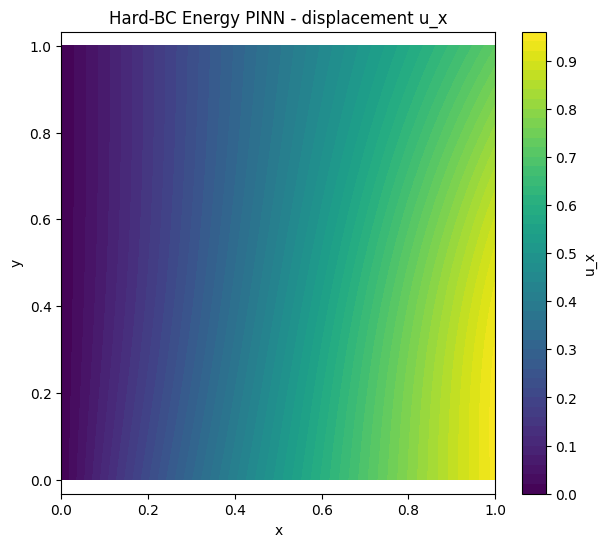

In [69]:
# ============================================================
# 55. Hard-BC Energy PINN：u_x 位移场
#
# 这次特别观察左侧：
#
#     x = 0
#
# 应该严格为 0，而不是之前大约 0.04 的残余位移。
# ============================================================

with torch.no_grad():

    u_pred_energy_hard = model_energy_hard(
        X_test_plate
    )

    u_x_energy_hard = (
        u_pred_energy_hard[:, 0]
        .reshape(N_grid, N_grid)
    )

    u_y_energy_hard = (
        u_pred_energy_hard[:, 1]
        .reshape(N_grid, N_grid)
    )


plt.figure(figsize=(7, 6))

plt.contourf(
    X_mesh.cpu(),
    Y_mesh.cpu(),
    u_x_energy_hard.cpu(),
    levels=50
)

plt.colorbar(label="u_x")

plt.xlabel("x")
plt.ylabel("y")

plt.title(
    "Hard-BC Energy PINN - displacement u_x"
)

plt.axis("equal")
plt.show()

PyTorch: 2.10.0+cu128
Device : cuda
GPU    : NVIDIA GeForce RTX 5060
lambda = 0.5769230769230769
mu     = 0.3846153846153846
Epoch     1 | Total 8.0567e-03 | Internal 9.9254e-02 | External -9.1197e-02
Epoch   250 | Total -4.3893e-01 | Internal 4.3681e-01 | External -8.7574e-01
Epoch   500 | Total -4.4148e-01 | Internal 4.3520e-01 | External -8.7669e-01
Epoch   750 | Total -4.4295e-01 | Internal 4.4294e-01 | External -8.8589e-01
Epoch  1000 | Total -4.4102e-01 | Internal 4.8809e-01 | External -9.2910e-01
Epoch  1250 | Total -4.4303e-01 | Internal 4.4364e-01 | External -8.8667e-01
Epoch  1500 | Total -4.4233e-01 | Internal 4.4431e-01 | External -8.8664e-01
Epoch  1750 | Total -4.4400e-01 | Internal 4.4350e-01 | External -8.8750e-01
Epoch  2000 | Total -4.4258e-01 | Internal 4.2725e-01 | External -8.6983e-01
Epoch  2250 | Total -4.4347e-01 | Internal 4.4217e-01 | External -8.8564e-01
Epoch  2500 | Total -4.4263e-01 | Internal 4.4437e-01 | External -8.8700e-01
Epoch  2750 | Total -4.4395e-

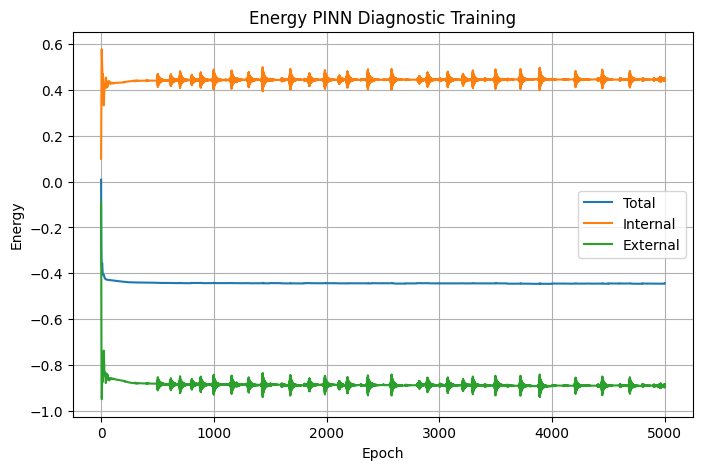

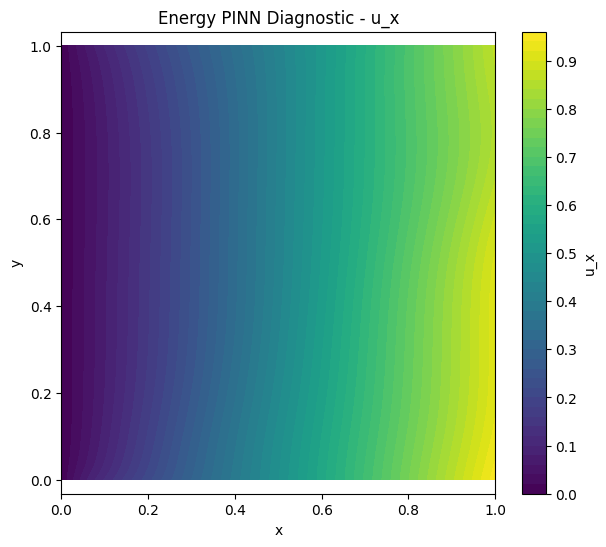

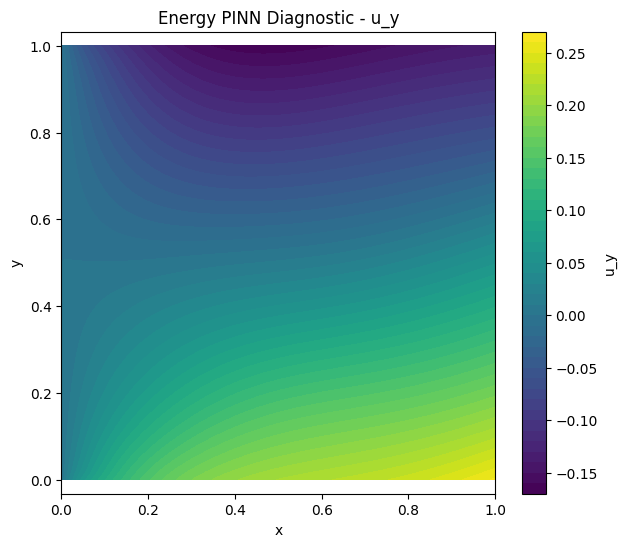

In [70]:
# ============================================================
# Energy PINN Diagnostic Run
#
# 目标：
# 1. 增加内部采样点数量
# 2. 训练时周期性重新采样 Monte Carlo 点
# 3. 延长训练轮数
# 4. 检查 Energy PINN 的 PDE residual 是否显著改善
#
# 物理模型：
# 2D Linear Elasticity, Plane Strain
#
# 区域：
# (x, y) ∈ [0, 1] × [0, 1]
#
# 边界：
# x = 0: u_x = u_y = 0  （Hard BC）
# x = 1: t_x = 1, t_y = 0
# y = 0, 1: traction = 0
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


# ============================================================
# 1. 基本环境
# ============================================================

torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))


# ============================================================
# 2. 物理参数
# ============================================================

Lx = 1.0
Ly = 1.0

E = 1.0
nu = 0.3

T = 1.0

lam = E * nu / (
    (1.0 + nu) * (1.0 - 2.0 * nu)
)

mu = E / (
    2.0 * (1.0 + nu)
)

print("lambda =", lam)
print("mu     =", mu)


# ============================================================
# 3. 网络
# ============================================================

class HardBCElasticityNet(nn.Module):

    def __init__(self, layers):
        super().__init__()

        self.layers = nn.ModuleList()

        for i in range(len(layers) - 1):
            self.layers.append(
                nn.Linear(
                    layers[i],
                    layers[i + 1]
                )
            )

        self.activation = nn.Tanh()

        self.apply(self._init_weights)


    def _init_weights(self, module):

        if isinstance(module, nn.Linear):

            nn.init.xavier_normal_(
                module.weight
            )

            nn.init.zeros_(
                module.bias
            )


    def forward(self, X):

        H = X

        for layer in self.layers[:-1]:
            H = self.activation(
                layer(H)
            )

        raw_u = self.layers[-1](H)

        x = X[:, 0:1]

        # Hard Dirichlet BC:
        # x = 0 时位移严格为 0
        u_x = x * raw_u[:, 0:1]
        u_y = x * raw_u[:, 1:2]

        return torch.cat(
            [u_x, u_y],
            dim=1
        )


layers = [
    2,
    64,
    64,
    64,
    64,
    2
]


# ============================================================
# 4. 自动微分工具
# ============================================================

def gradients(y, x):

    return torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True
    )[0]


# ============================================================
# 5. 位移 -> 应变
# ============================================================

def compute_strain(model, X):

    X = X.requires_grad_(True)

    u = model(X)

    u_x = u[:, 0:1]
    u_y = u[:, 1:2]

    grad_u_x = gradients(
        u_x,
        X
    )

    grad_u_y = gradients(
        u_y,
        X
    )

    dux_dx = grad_u_x[:, 0:1]
    dux_dy = grad_u_x[:, 1:2]

    duy_dx = grad_u_y[:, 0:1]
    duy_dy = grad_u_y[:, 1:2]

    eps_xx = dux_dx

    eps_yy = duy_dy

    eps_xy = 0.5 * (
        dux_dy
        +
        duy_dx
    )

    return (
        u_x,
        u_y,
        eps_xx,
        eps_yy,
        eps_xy
    )


# ============================================================
# 6. 应变 -> 应力
# ============================================================

def compute_stress(
    eps_xx,
    eps_yy,
    eps_xy
):

    trace_eps = (
        eps_xx
        +
        eps_yy
    )

    sigma_xx = (
        lam * trace_eps
        +
        2.0 * mu * eps_xx
    )

    sigma_yy = (
        lam * trace_eps
        +
        2.0 * mu * eps_yy
    )

    sigma_xy = (
        2.0 * mu * eps_xy
    )

    return (
        sigma_xx,
        sigma_yy,
        sigma_xy
    )


def displacement_strain_stress(
    model,
    X
):

    (
        u_x,
        u_y,
        eps_xx,
        eps_yy,
        eps_xy
    ) = compute_strain(
        model,
        X
    )

    (
        sigma_xx,
        sigma_yy,
        sigma_xy
    ) = compute_stress(
        eps_xx,
        eps_yy,
        eps_xy
    )

    return (
        u_x,
        u_y,
        eps_xx,
        eps_yy,
        eps_xy,
        sigma_xx,
        sigma_yy,
        sigma_xy
    )


# ============================================================
# 7. Monte Carlo 内部采样
# ============================================================

def sample_interior(N):

    x = Lx * torch.rand(
        N, 1,
        device=device
    )

    y = Ly * torch.rand(
        N, 1,
        device=device
    )

    return torch.cat(
        [x, y],
        dim=1
    )


# ============================================================
# 8. 固定边界采样
# ============================================================

N_b = 1000

# 右边界
y_right = Ly * torch.rand(
    N_b, 1,
    device=device
)

x_right = torch.full_like(
    y_right,
    Lx
)

X_right = torch.cat(
    [x_right, y_right],
    dim=1
)

# 左边界
y_left = Ly * torch.rand(
    N_b, 1,
    device=device
)

x_left = torch.zeros_like(
    y_left
)

X_left = torch.cat(
    [x_left, y_left],
    dim=1
)

# 上边界
x_top = Lx * torch.rand(
    N_b, 1,
    device=device
)

y_top = torch.full_like(
    x_top,
    Ly
)

X_top = torch.cat(
    [x_top, y_top],
    dim=1
)

# 下边界
x_bottom = Lx * torch.rand(
    N_b, 1,
    device=device
)

y_bottom = torch.zeros_like(
    x_bottom
)

X_bottom = torch.cat(
    [x_bottom, y_bottom],
    dim=1
)


# ============================================================
# 9. 内部应变能
# ============================================================

def compute_internal_energy(
    model,
    X_i
):

    X = (
        X_i.clone()
        .detach()
        .requires_grad_(True)
    )

    (
        u_x,
        u_y,
        eps_xx,
        eps_yy,
        eps_xy,
        sigma_xx,
        sigma_yy,
        sigma_xy
    ) = displacement_strain_stress(
        model,
        X
    )

    energy_density = 0.5 * (
        sigma_xx * eps_xx
        +
        sigma_yy * eps_yy
        +
        2.0 * sigma_xy * eps_xy
    )

    area = (
        Lx * Ly
    )

    internal_energy = (
        area
        *
        torch.mean(
            energy_density
        )
    )

    return internal_energy


# ============================================================
# 10. 外力势能
# ============================================================

def compute_external_potential(
    model,
    X_right
):

    u_right = model(
        X_right
    )

    u_x_right = (
        u_right[:, 0:1]
    )

    boundary_length = Ly

    external_potential = (
        -boundary_length
        *
        torch.mean(
            T * u_x_right
        )
    )

    return external_potential


# ============================================================
# 11. Energy Loss
# ============================================================

def energy_loss(
    model,
    X_i,
    X_right
):

    internal_energy = (
        compute_internal_energy(
            model,
            X_i
        )
    )

    external_potential = (
        compute_external_potential(
            model,
            X_right
        )
    )

    total = (
        internal_energy
        +
        external_potential
    )

    return (
        total,
        internal_energy,
        external_potential
    )


# ============================================================
# 12. PDE residual：只用于训练后的独立评估
# ============================================================

def compute_pde_residual(
    model,
    X
):

    X = (
        X.clone()
        .detach()
        .requires_grad_(True)
    )

    (
        u_x,
        u_y,
        eps_xx,
        eps_yy,
        eps_xy,
        sigma_xx,
        sigma_yy,
        sigma_xy
    ) = displacement_strain_stress(
        model,
        X
    )

    grad_sigma_xx = gradients(
        sigma_xx,
        X
    )

    grad_sigma_yy = gradients(
        sigma_yy,
        X
    )

    grad_sigma_xy = gradients(
        sigma_xy,
        X
    )

    residual_x = (
        grad_sigma_xx[:, 0:1]
        +
        grad_sigma_xy[:, 1:2]
    )

    residual_y = (
        grad_sigma_xy[:, 0:1]
        +
        grad_sigma_yy[:, 1:2]
    )

    return (
        residual_x,
        residual_y
    )


# ============================================================
# 13. traction
# ============================================================

def compute_traction(
    model,
    X,
    n_x,
    n_y
):

    X = (
        X.clone()
        .detach()
        .requires_grad_(True)
    )

    (
        u_x,
        u_y,
        eps_xx,
        eps_yy,
        eps_xy,
        sigma_xx,
        sigma_yy,
        sigma_xy
    ) = displacement_strain_stress(
        model,
        X
    )

    t_x = (
        sigma_xx * n_x
        +
        sigma_xy * n_y
    )

    t_y = (
        sigma_xy * n_x
        +
        sigma_yy * n_y
    )

    return (
        t_x,
        t_y
    )


# ============================================================
# 14. 创建 Energy PINN
# ============================================================

torch.manual_seed(42)

model = HardBCElasticityNet(
    layers
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


# ============================================================
# 15. 训练配置
# ============================================================

N_i = 20000

epochs = 5000

resample_every = 100

history_total = []
history_internal = []
history_external = []


# ============================================================
# 16. Energy PINN 训练
#
# 每 100 epoch 重新采样一次内部 Monte Carlo 点。
# 这样不会长期依赖同一组离散积分点。
# ============================================================

X_i = sample_interior(
    N_i
)

for epoch in range(
    1,
    epochs + 1
):

    # ==============================
    # 周期性重新采样
    # ==============================

    if (
        epoch == 1
        or
        epoch % resample_every == 0
    ):

        X_i = sample_interior(
            N_i
        )


    optimizer.zero_grad()

    (
        loss_total,
        internal_energy,
        external_potential
    ) = energy_loss(
        model,
        X_i,
        X_right
    )

    loss_total.backward()

    optimizer.step()


    history_total.append(
        loss_total.item()
    )

    history_internal.append(
        internal_energy.item()
    )

    history_external.append(
        external_potential.item()
    )


    if (
        epoch == 1
        or
        epoch % 250 == 0
    ):

        print(
            f"Epoch {epoch:5d} | "
            f"Total {loss_total.item():.4e} | "
            f"Internal {internal_energy.item():.4e} | "
            f"External {external_potential.item():.4e}"
        )


# ============================================================
# 17. 检查 Hard BC
# ============================================================

model.eval()

with torch.no_grad():

    u_left = model(
        X_left
    )

print()
print(
    "max |u_x(left)| =",
    torch.max(
        torch.abs(
            u_left[:, 0]
        )
    ).item()
)

print(
    "max |u_y(left)| =",
    torch.max(
        torch.abs(
            u_left[:, 1]
        )
    ).item()
)


# ============================================================
# 18. 独立评估 PDE residual
# ============================================================

X_eval = sample_interior(
    20000
)

res_x, res_y = (
    compute_pde_residual(
        model,
        X_eval
    )
)

pde_mse = (
    torch.mean(
        res_x**2
    )
    +
    torch.mean(
        res_y**2
    )
)

print()
print(
    "PDE MSE =",
    pde_mse.item()
)


# ============================================================
# 19. 右边界 traction
# ============================================================

n_right_x = torch.ones(
    N_b,
    1,
    device=device
)

n_right_y = torch.zeros(
    N_b,
    1,
    device=device
)

t_rx, t_ry = compute_traction(
    model,
    X_right,
    n_right_x,
    n_right_y
)

right_mse = (
    torch.mean(
        (t_rx - T)**2
    )
    +
    torch.mean(
        t_ry**2
    )
)

print()
print(
    "Right mean t_x =",
    torch.mean(
        t_rx
    ).item()
)

print(
    "Right mean t_y =",
    torch.mean(
        t_ry
    ).item()
)

print(
    "Right traction MSE =",
    right_mse.item()
)


# ============================================================
# 20. 上下自由边界
# ============================================================

n_top_x = torch.zeros(
    N_b,
    1,
    device=device
)

n_top_y = torch.ones(
    N_b,
    1,
    device=device
)

t_tx, t_ty = compute_traction(
    model,
    X_top,
    n_top_x,
    n_top_y
)

top_mse = (
    torch.mean(
        t_tx**2
    )
    +
    torch.mean(
        t_ty**2
    )
)


n_bottom_x = torch.zeros(
    N_b,
    1,
    device=device
)

n_bottom_y = -torch.ones(
    N_b,
    1,
    device=device
)

t_bx, t_by = compute_traction(
    model,
    X_bottom,
    n_bottom_x,
    n_bottom_y
)

bottom_mse = (
    torch.mean(
        t_bx**2
    )
    +
    torch.mean(
        t_by**2
    )
)

print()
print(
    "Top traction MSE =",
    top_mse.item()
)

print(
    "Bottom traction MSE =",
    bottom_mse.item()
)


# ============================================================
# 21. 训练历史
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_total,
    label="Total"
)

plt.plot(
    history_internal,
    label="Internal"
)

plt.plot(
    history_external,
    label="External"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Energy"
)

plt.title(
    "Energy PINN Diagnostic Training"
)

plt.legend()

plt.grid(
    True
)

plt.show()


# ============================================================
# 22. 位移场可视化
# ============================================================

N_grid = 101

x_grid = torch.linspace(
    0.0,
    Lx,
    N_grid,
    device=device
)

y_grid = torch.linspace(
    0.0,
    Ly,
    N_grid,
    device=device
)

X_mesh, Y_mesh = torch.meshgrid(
    x_grid,
    y_grid,
    indexing="xy"
)

X_test = torch.stack(
    [
        X_mesh.reshape(-1),
        Y_mesh.reshape(-1)
    ],
    dim=1
)

with torch.no_grad():

    u_pred = model(
        X_test
    )

    u_x = (
        u_pred[:, 0]
        .reshape(
            N_grid,
            N_grid
        )
    )

    u_y = (
        u_pred[:, 1]
        .reshape(
            N_grid,
            N_grid
        )
    )


plt.figure(
    figsize=(7, 6)
)

plt.contourf(
    X_mesh.cpu(),
    Y_mesh.cpu(),
    u_x.cpu(),
    levels=50
)

plt.colorbar(
    label="u_x"
)

plt.xlabel("x")
plt.ylabel("y")

plt.title(
    "Energy PINN Diagnostic - u_x"
)

plt.axis(
    "equal"
)

plt.show()


plt.figure(
    figsize=(7, 6)
)

plt.contourf(
    X_mesh.cpu(),
    Y_mesh.cpu(),
    u_y.cpu(),
    levels=50
)

plt.colorbar(
    label="u_y"
)

plt.xlabel("x")
plt.ylabel("y")

plt.title(
    "Energy PINN Diagnostic - u_y"
)

plt.axis(
    "equal"
)

plt.show()

In [71]:
print("PDE MSE =", pde_mse.item())

PDE MSE = 1.557177186012268
